# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources (README.md file)
- Happy learning!

In [1]:
# import numpy and pandas
import pandas as pd
import numpy as np
from scipy.stats import trim_mean, mode, skew, gaussian_kde, pearsonr, spearmanr, beta
from statsmodels.stats.weightstats import ztest as ztest

from scipy.stats import ttest_ind, norm, t
from scipy.stats import f_oneway
from scipy.stats import sem

# Challenge 1 - Exploring the Data

In this challenge, we will examine all salaries of employees of the City of Chicago. We will start by loading the dataset and examining its contents

In [2]:
# Run this code:
salaries = pd.read_csv('../data/Current_Employee_Names__Salaries__and_Position_Titles.csv')

Examine the `salaries` dataset using the `head` function below.

In [3]:
salaries.head()

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",SERGEANT,POLICE,F,Salary,NaN,101442.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),POLICE,F,Salary,NaN,94122.0,NaN
2,"AARON, KIMBERLEI R",CHIEF CONTRACT EXPEDITER,GENERAL SERVICES,F,Salary,NaN,101592.0,NaN
3,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,WATER MGMNT,F,Salary,NaN,110064.0,NaN
4,"ABASCAL, REECE E",TRAFFIC CONTROL AIDE-HOURLY,OEMC,P,Hourly,20.0,NaN,19.86


In [4]:
salaries.shape

(33183, 8)

In [5]:
salaries.isna().sum()

Name                     0
Job Titles               0
Department               0
Full or Part-Time        0
Salary or Hourly         0
Typical Hours        25161
Annual Salary         8022
Hourly Rate          25161
dtype: int64

In [6]:
salaries.dtypes

Name                  object
Job Titles            object
Department            object
Full or Part-Time     object
Salary or Hourly      object
Typical Hours        float64
Annual Salary        float64
Hourly Rate          float64
dtype: object

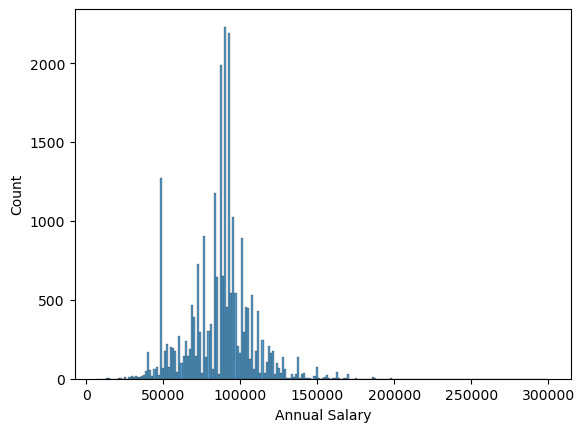

In [10]:
import seaborn as sns

sns.histplot(
        salaries \
            .dropna(subset='Annual Salary') \
            .loc[:, 'Annual Salary']
);

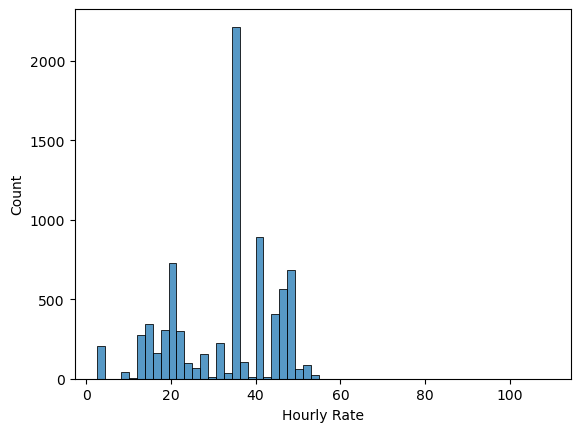

In [11]:
sns.histplot(
        salaries \
            .dropna(subset='Hourly Rate') \
            .loc[:, 'Hourly Rate']
);

# Challenge 2
This is a placeholder to make the AI corrector be able to find the correct exercise for feedback

# Challenge 3 - Constructing Confidence Intervals

We will test whether the hourly wage of all hourly workers is significantly different from $30/hr.

In the cell below, we will construct a 95% confidence interval for the mean hourly wage of all hourly workers. Is $30/hr within that interval?

The confidence interval is computed in SciPy using the `t.interval` function. You can read more about this function [here](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.t.html).

To compute the confidence interval of the hourly wage, use the 0.95 for the confidence level, number of rows - 1 for degrees of freedom, the mean of the sample for the location parameter and the standard error for the scale. The standard error can be computed using [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html) function in SciPy.

In [40]:
confidence_level = .95

wage_n = salaries.loc[salaries['Salary or Hourly'] == 'Hourly', 'Hourly Rate'].count()

wage_mean = salaries.loc[salaries['Salary or Hourly'] == 'Hourly', 'Hourly Rate'].mean()

wage_std = salaries.loc[salaries['Salary or Hourly'] == 'Hourly', 'Hourly Rate'].std()

wage_se = wage_std / np.sqrt(wage_n)

wage_se = salaries.loc[salaries['Salary or Hourly'] == 'Hourly', 'Hourly Rate'].sem() # easier way to calculate SE



In [41]:
print(f'CL: {confidence_level}')
print(f'N: {wage_n}')
print(f'Sample mean: {round(wage_mean, 2)}')
print(f'Sample std: {round(wage_std, 2)}')
print(f'Sample SE: {round(wage_se, 2)}')

CL: 0.95
N: 8022
Sample mean: 32.79
Sample std: 12.11
Sample SE: 0.14


In [45]:
wage_ci = t.interval(confidence_level, df=wage_n - 1, loc=wage_mean, scale=wage_se)

wage_ci

(32.52345834488425, 33.05365708767623)

In [ ]:
"""
CI suggest with 95% confidence that the population mean wage is between 32.5 and 33.05. 
Since 30 is outside that range then we can say it's significantly different
"""

This is fine if we have thousands of worker data. But what if we have only 100 workers data?

Sample 100 workers and re-construct the 95% confidence interval. Is the interval wider of narrower? And why?
Do you still encapsulate the $30/hr mark in this case?

In [63]:
wage_sample = salaries.loc[salaries['Salary or Hourly'] == "Hourly"].sample(100)

In [65]:
wage_sample['Hourly Rate'].mean()

33.451600000000006

In [67]:
wage_ci = t.interval(
    confidence_level, 
    df=wage_sample['Hourly Rate'].count() - 1, 
    loc=wage_sample['Hourly Rate'].mean(), 
    scale=wage_sample['Hourly Rate'].sem())

wage_ci

(30.791890572702624, 36.11130942729739)

In [68]:
"""
CI become significantly wider due to lower n because:
- Lower n increases the SE (denominator becomes smaller)
- Slight increas in t crital value due to lower df

30 is still outside the obtained CI, so the population mean wage is still siginificantly different from 30 under 95% CL

But with wider interval it's more ikely that 30 would be inside te interval if we were draw a different sample
"""

"\nCI become significantly wider due to lower n because:\n- Lower n increases the SE (denominator becomes smaller)\n- Slight increas in t crital value due to lower df\n\n30 is still outside the obtained CI, so the population mean wage is still siginificantly different from 30 under 95% CL\n\nBut with wider interval it's more ikely that 30 would be inside te interval if we were draw a different sample\n"